# Notebook 01: Theory and Discretization
### Modeling a vibrating string and turning integrals into code

When I play guitar, notes don't just have pitch—they have *timbre*, that warm, full feeling in the sound. I wanted to see if I could strip away the vague words and measure that sound in actual numbers.

I started with the physics of an ideal vibrating string of length $L$ clamped at both ends ($u(0,t) = u(L,t) = 0$):
$$\frac{\partial^2 u}{\partial t^2} = c^2 \frac{\partial^2 u}{\partial x^2}$$

Separating variables into space $X(x)$ and time $T(t)$ gave standing wave modes $\sin\left(\frac{n\pi x}{L}\right)$ at frequencies $\omega_n = \frac{n\pi c}{L}$. By superposition, the full vibration is just the sum of these sinusoidal modes:
$$u(x,t) = \sum_{n=1}^\infty \left( A_n \cos(\omega_n t) + B_n \sin(\omega_n t) \right) \sin\left( \frac{n\pi x}{L} \right)$$

This gave me the physical green light to treat sine and cosine waves as the literal building blocks of guitar timbre.


In [1]:
import sys
from pathlib import Path

# make sure we can import from src/
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import matplotlib.pyplot as plt

from src.dft_engine import manual_dft
from src.visualization import plot_riemann_sum, plot_aliasing, plot_unit_circle


## 1. From Continuous Integrals to Discrete Slices

The continuous Fourier coefficient formula over period $T$ is:
$$c_k = \frac{1}{T} \int_0^T f(t) e^{-i k \omega_0 t} \, dt$$

At first, I spent hours wondering how code was supposed to handle that $1/T$ integral when all I had were discrete data points from a file. It clicked when I drew out Riemann rectangles.
The base of each rectangle is $\Delta t = T / N$. When you substitute that into the Riemann sum:
$$c_k \approx \frac{1}{T} \sum_{n=0}^{N-1} f(t_n) e^{-i k (2\pi/T)(n \Delta t)} \Delta t = \frac{1}{T} \sum_{n=0}^{N-1} x_n e^{-i 2\pi k n / N} \left(\frac{T}{N}\right) = \frac{1}{N} \sum_{n=0}^{N-1} x_n e^{-i 2\pi k n / N}$$

The time duration $T$ cancels out completely! We are left with the discrete $1/N$ factor replacing the continuous $1/T$ integration.
That gave me confidence that the DFT isn't a black-box trick; it's literally just the continuous integral cut into $N$ rectangular slices.


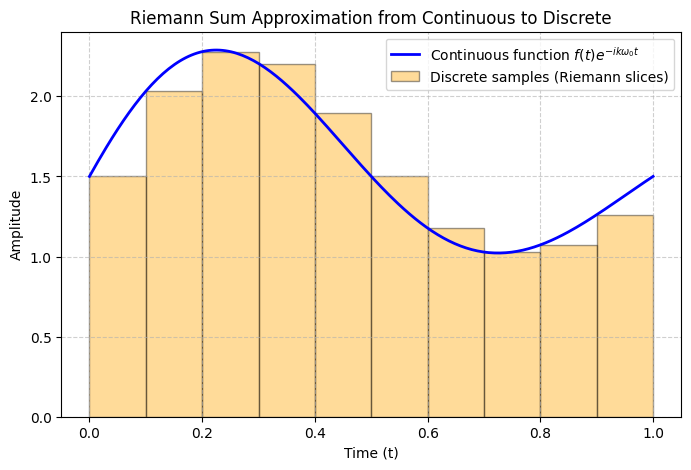

In [2]:
# continuous curve sliced into n=10 discrete riemann rectangles
fig_riemann = plot_riemann_sum()
plt.show()


## 2. Sampling Limits: Aliasing and Bin Resolution

Working with discrete audio samples forces two hard mathematical constraints:

1. **Frequency Resolution ($\Delta f = 1/T$):** The DFT sorts energy into discrete frequency bins spaced by $\Delta f = 1/T$. For our $0.05\text{ s}$ analysis window, $\Delta f = 1/0.05 = 20\text{ Hz}$. We can only distinguish frequencies in steps of $20\text{ Hz}$.
2. **Nyquist Limit ($f_s / 2$):** For CD audio at $f_s = 44,100\text{ Hz}$, the maximum frequency we can accurately record without aliasing is $22,050\text{ Hz}$. If a wave oscillates faster than half the sample clock, the discrete dots get connected into a false low-frequency ghost wave.

Here is what happens when a $9\text{ Hz}$ wave is sampled at only $10\text{ Hz}$—it looks identically like a $-1\text{ Hz}$ alias wave.


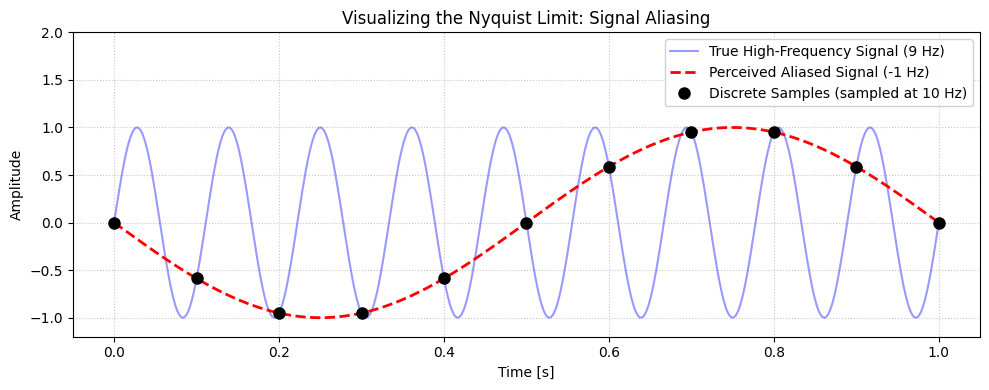

In [3]:
# 9hz wave sampled at 10hz aliases down to perceived 1hz
fig_aliasing = plot_aliasing()
plt.show()


## 3. Walking the Complex Unit Circle

Instead of juggling separate sines and cosines, Euler's formula $e^{-i\theta} = \cos\theta - i\sin\theta$ wraps everything into a single rotating vector.
For $N=4$, the DFT basis functions rotate by $90^\circ$ ($\pi/2$ radians) each step:
- $n=0 \implies e^0 = 1$
- $n=1 \implies e^{-i\pi/2} = -i$
- $n=2 \implies e^{-i\pi} = -1$
- $n=3 \implies e^{-i3\pi/2} = i$


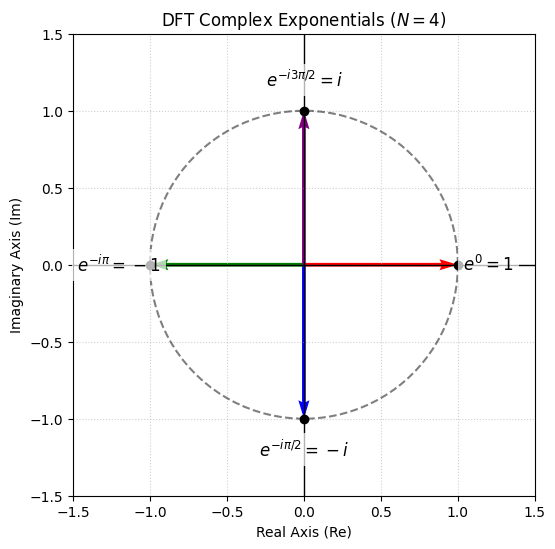

In [4]:
# argand diagram of the 4 complex roots of unity
fig_unit_circle = plot_unit_circle()
plt.show()


## 4. Hand-Calculating a 4-Point Toy Signal

To verify the summation formula before running it on thousands of audio samples, I tested it on a simple toy wave $x_n = [1, 0, -1, 0]$:
- For $X_1$ ($k=1$, testing for matching wave):
  $$X_1 = (1)(1) + (0)(-i) + (-1)(-1) + (0)(i) = 1 + 0 + 1 + 0 = 2$$
- For $X_0$ ($k=0$, testing for DC offset):
  $$X_0 = (1)(1) + (0)(1) + (-1)(1) + (0)(1) = 1 + 0 - 1 + 0 = 0$$

The math constructively interferes to 2 for matching frequencies and destructively cancels to 0 for mismatched ones.


In [5]:
# test our manual loop on the toy signal worked out by hand
toy_signal = np.array([1.0, 0.0, -1.0, 0.0])
toy_coeffs = manual_dft(toy_signal, vectorized=False)

print(f"Toy signal: {toy_signal}")
print(f"X_0 (DC offset):          {toy_coeffs[0].real:.1f} + {toy_coeffs[0].imag:.1f}i (expected 0)")
print(f"X_1 (matching frequency): {toy_coeffs[1].real:.1f} + {toy_coeffs[1].imag:.1f}i (expected 2)")

assert np.isclose(toy_coeffs[0], 0.0)
assert np.isclose(toy_coeffs[1], 2.0)
print("\nhand calculation matches code output perfectly")


Toy signal: [ 1.  0. -1.  0.]
X_0 (DC offset):          0.0 + 0.0i (expected 0)
X_1 (matching frequency): 2.0 + 0.0i (expected 2)

hand calculation matches code output perfectly
